## Описание задания

**Цель работы:** изучение методов прогнозирования временных рядов.

**Задание:**
1. Выбрать набор данных для задачи прогнозирования временного ряда.
2. Визуализировать временной ряд и его основные характеристики.
3. Разделить временной ряд на обучающую и тестовую выборку.
4. Произвести прогнозирование следующими методами:
   - авторегрессионный метод **SARIMA**;
   - метод символьной регрессии (`gplearn`);
   - два метода из семейства МГУА — линейный **COMBI** и нелинейный **MIA** (библиотека `gmdh`).
5. Визуализировать тестовую выборку и каждый из прогнозов.
6. Оценить качество прогноза метриками MAE, RMSE и MAPE.

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Загрузка данных

Используется датасет **Mauna Loa CO₂** из репозитория NOAA, встроенный в библиотеку `statsmodels`.
Содержит еженедельные измерения концентрации углекислого газа в атмосфере (1958–2001, станция Мауна-Лоа, Гавайи).

**Задача регрессии временного ряда:** по предыстории концентрации CO₂ предсказать её значения
на следующие 24 месяца.

Исходные еженедельные данные агрегируются до **ежемесячных** средних, пропуски заполняются
линейной интерполяцией.

In [2]:
co2_raw = sm.datasets.co2.load_pandas()
df = co2_raw.data.resample('ME').mean()
df['co2'] = df['co2'].interpolate(method='linear')

print('Период:         ', df.index.min().date(), '—', df.index.max().date())
print('Наблюдений:     ', len(df))
print('Пропусков:      ', df['co2'].isna().sum())
print('Мин / Макс CO₂:', round(df['co2'].min(), 2), '/', round(df['co2'].max(), 2), 'ppm')
df.head(8)

Период:          1958-03-31 — 2001-12-31
Наблюдений:      526
Пропусков:       0
Мин / Макс CO₂: 313.4 / 373.8 ppm


,co2
1958-03-31,316.100000
1958-04-30,317.200000
1958-05-31,317.433333
1958-06-30,316.529167
1958-07-31,315.625000
1958-08-31,314.950000
1958-09-30,313.500000
1958-10-31,313.462500


## 3. Визуализация временного ряда и его характеристик

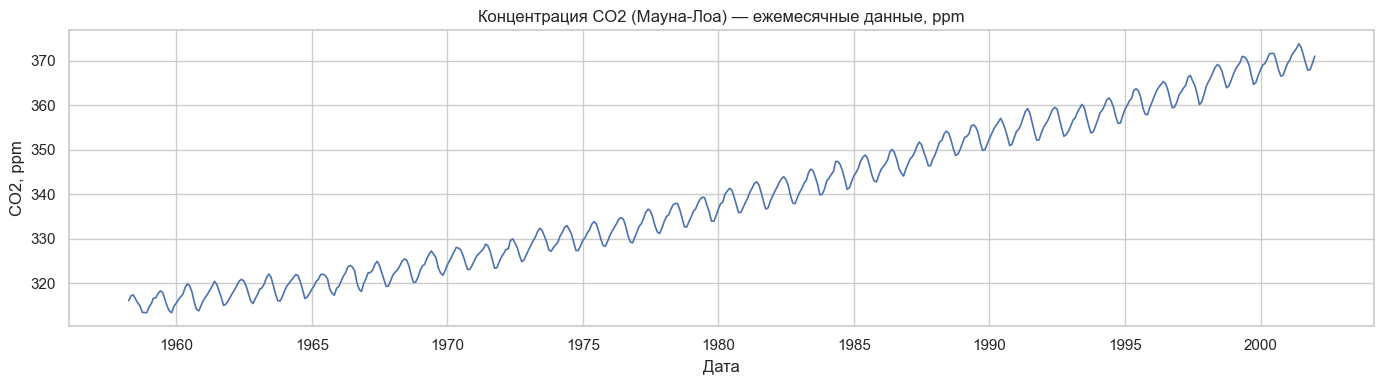

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['co2'], color='#4C72B0', lw=1.2)
ax.set_title('Концентрация CO2 (Мауна-Лоа) — ежемесячные данные, ppm')
ax.set_xlabel('Дата')
ax.set_ylabel('CO2, ppm')
plt.tight_layout()
plt.show()

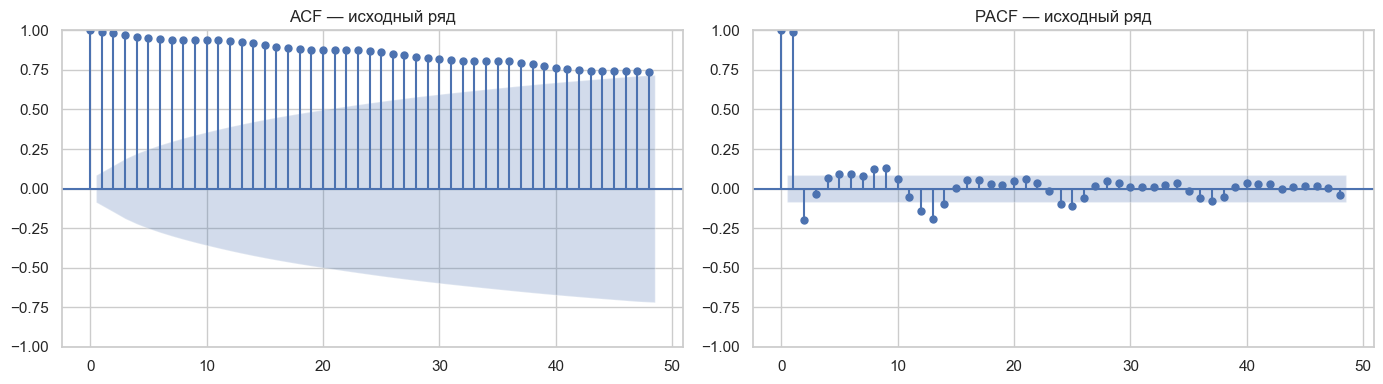

Исходный ряд               ADF=  2.2328  p=0.9989  → нестационарен (α=0.05)
Первая разность            ADF= -4.7519  p=0.0001  → стационарен (α=0.05)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['co2'], lags=48, ax=axes[0])
axes[0].set_title('ACF — исходный ряд')
plot_pacf(df['co2'], lags=48, ax=axes[1])
axes[1].set_title('PACF — исходный ряд')
plt.tight_layout()
plt.show()

# Тест Дики–Фуллера
for label, series in [('Исходный ряд', df['co2']),
                       ('Первая разность', df['co2'].diff().dropna())]:
    adf = adfuller(series)
    verdict = 'стационарен' if adf[1] < 0.05 else 'нестационарен'
    print(f'{label:25s}  ADF={adf[0]:8.4f}  p={adf[1]:.4f}  → {verdict} (α=0.05)')

## 4. Разделение на обучающую и тестовую выборки

Последние **24 месяца** (2 года) отводятся под тестовую выборку.
Прогнозирование выполняется **рекурсивно** (многошаговое): каждый следующий шаг использует
предсказанные значения как входные данные.

Обучение: 502 наблюдений  1958-03-31 — 1999-12-31
Тест:     24  наблюдений  2000-01-31 — 2001-12-31


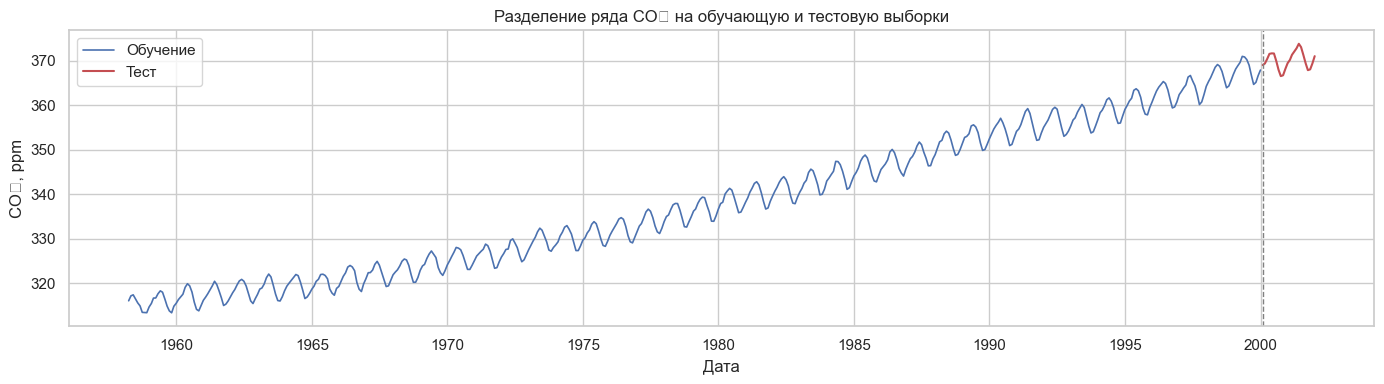

In [5]:
N_TEST  = 24
N_LAGS  = 12

train = df['co2'].iloc[:-N_TEST]
test  = df['co2'].iloc[-N_TEST:]

print(f'Обучение: {len(train)} наблюдений  {train.index[0].date()} — {train.index[-1].date()}')
print(f'Тест:     {len(test)}  наблюдений  {test.index[0].date()} — {test.index[-1].date()}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train, label='Обучение', color='#4C72B0', lw=1.2)
ax.plot(test.index,  test,  label='Тест',     color='#C44E52', lw=1.5)
ax.axvline(test.index[0], color='grey', ls='--', lw=1)
ax.set_title('Разделение ряда CO₂ на обучающую и тестовую выборки')
ax.set_xlabel('Дата')
ax.set_ylabel('CO₂, ppm')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Авторегрессионный метод — SARIMA

**SARIMA(p, d, q)(P, D, Q, s)** — сезонная авторегрессионная интегрированная модель скользящего среднего.

- Тест Дики–Фуллера показал нестационарность исходного ряда → берём **d=1** (первое дифференцирование).
- Ряд имеет выраженную годовую сезонность → добавляем сезонную компоненту с **s=12**.
- Порядки p, q, P, Q выбраны равными 1 на основе анализа ACF/PACF.

In [6]:
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)

print(f'AIC: {sarima_fit.aic:.2f}   BIC: {sarima_fit.bic:.2f}')

arima_pred = sarima_fit.forecast(steps=N_TEST)
arima_pred.index = test.index
print('Прогноз SARIMA получен.')

AIC: 208.19   BIC: 229.01
Прогноз SARIMA получен.


## 6. Символьная регрессия — `gplearn`

**Символьная регрессия** (genetic programming) автоматически ищет аналитическую формулу,
связывающую лаговые признаки с прогнозируемым значением.

**Подготовка данных:**
Временной ряд преобразуется в задачу регрессии с помощью скользящего окна из **N_LAGS = 12** лагов:

$$X[t] = [y_{t-12},\, y_{t-11},\, \ldots,\, y_{t-1}], \quad \text{target} = y_t$$

Прогноз на тестовом горизонте строится **рекурсивно** — каждый новый прогноз добавляется в окно.

In [7]:
def make_lag_matrix(values, n_lags):
    X, y = [], []
    for i in range(n_lags, len(values)):
        X.append(values[i - n_lags:i])
        y.append(values[i])
    return np.array(X, dtype=float), np.array(y, dtype=float)

all_values  = df['co2'].values
X_all, y_all = make_lag_matrix(all_values, N_LAGS)

train_sz  = len(train) - N_LAGS
X_tr, y_tr = X_all[:train_sz],          y_all[:train_sz]
X_te, y_te = X_all[train_sz:train_sz+N_TEST], y_all[train_sz:train_sz+N_TEST]

print('X_tr:', X_tr.shape, '  y_tr:', y_tr.shape)
print('X_te:', X_te.shape, '  y_te:', y_te.shape)

def recursive_forecast(predict_fn, last_values, n_steps, n_lags):
    hist = list(last_values[-n_lags:].copy())
    preds = []
    for _ in range(n_steps):
        x = np.array(hist[-n_lags:]).reshape(1, -1)
        preds.append(float(np.asarray(predict_fn(x)).ravel()[0]))
        hist.append(preds[-1])
    return np.array(preds)

X_tr: (490, 12)   y_tr: (490,)
X_te: (24, 12)   y_te: (24,)


In [8]:
sr_available = True
try:
    from gplearn.genetic import SymbolicRegressor
    print('gplearn импортирован.')
except ImportError as e:
    sr_available = False
    print('gplearn недоступен:', e)

sr_pred = None
if sr_available:
    sr = SymbolicRegressor(
        population_size=500,
        generations=20,
        function_set=['add', 'sub', 'mul', 'div'],
        parsimony_coefficient=0.005,
        max_samples=1.0,
        verbose=0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    sr.fit(X_tr, y_tr)
    print('Лучшая формула:', sr._program)

    sr_pred = recursive_forecast(
        lambda x: sr.predict(x),
        train.values, N_TEST, N_LAGS,
    )
    print('Прогноз символьной регрессии получен.')

gplearn импортирован.
Лучшая формула: sub(sub(add(X0, div(X11, X0)), -0.121), -0.121)
Прогноз символьной регрессии получен.


## 7. Методы МГУА — `gmdh`

**Метод группового учёта аргументов (МГУА)** — самоорганизующийся итерационный алгоритм,
автоматически строящий полиномиальную модель путём последовательного отбора лучших частных описаний.

- **COMBI** — линейный комбинаторный алгоритм.
- **MIA** — нелинейный многослойный итерационный алгоритм.

Входными признаками служат те же 12 лаговых значений, что и для символьной регрессии.
Прогноз строится рекурсивно.

In [9]:
gmdh_available = True
try:
    from gmdh import Combi, Mia
    print('gmdh импортирован.')
except ImportError as e:
    gmdh_available = False
    print('gmdh недоступен:', e)

combi_pred = mia_pred = None
if gmdh_available:
    combi = Combi()
    combi.fit(X_tr, y_tr)
    combi_pred = recursive_forecast(
        lambda x: combi.predict(x),
        train.values, N_TEST, N_LAGS,
    )
    print('COMBI обучен.')
    try:
        print('Полином:', combi.get_best_polynomial())
    except Exception:
        pass

    print()
    mia = Mia()
    mia.fit(X_tr, y_tr)
    mia_pred = recursive_forecast(
        lambda x: mia.predict(x),
        train.values, N_TEST, N_LAGS,
    )
    print('MIA обучен.')

gmdh импортирован.
COMBI обучен.
Полином: y = 0.4473*x3 - 0.2163*x5 - 0.1059*x6 + 0.2401*x7 - 0.2185*x10 - 0.1698*x11 + 1.034*x12 - 3.2265

MIA обучен.


## 8. Оценка качества и сравнение методов

Используются три метрики:
- **MAE** — средняя абсолютная ошибка;
- **RMSE** — корень из среднеквадратичной ошибки;
- **MAPE** — средняя абсолютная процентная ошибка;
- **R²** — коэффициент детерминации (чем ближе к 1, тем лучше).

In [10]:
def mape(y_true, y_pred):
    return float(np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100)

def evaluate(name, y_true, y_pred):
    yt, yp = np.array(y_true), np.array(y_pred)
    return {
        'Метод':    name,
        'MAE':      mean_absolute_error(yt, yp),
        'RMSE':     float(np.sqrt(mean_squared_error(yt, yp))),
        'MAPE, %':  mape(yt, yp),
        'R²':       r2_score(yt, yp),
    }

results = [evaluate('SARIMA(1,1,1)(1,1,1,12)', test.values, arima_pred.values)]
if sr_pred    is not None: results.append(evaluate('Символьная регрессия', y_te, sr_pred))
if combi_pred is not None: results.append(evaluate('МГУА: COMBI (линейный)', y_te, combi_pred))
if mia_pred   is not None: results.append(evaluate('МГУА: MIA (нелинейный)', y_te, mia_pred))

results_df = pd.DataFrame(results).set_index('Метод').sort_values('RMSE')
results_df.round(4)

/var/folders/ph/8fl6x2q92mj57yqwcd2l9gh80000gn/T/ipykernel_8140/3045385616.py:24: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ph/8fl6x2q92mj57yqwcd2l9gh80000gn/T/ipykernel_8140/3045385616.py:24: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/semyon/Desktop/TMO/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/semyon/Desktop/TMO/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/semyon/Desktop/TMO/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/semyon/Desktop/TMO/.venv/

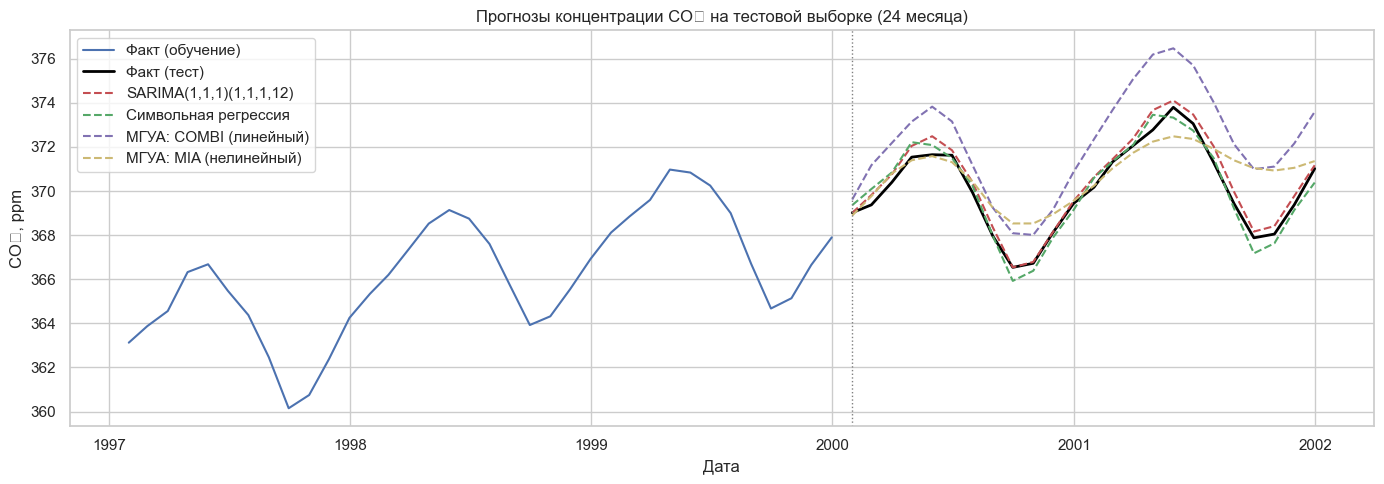

In [11]:
# ── Прогноз vs факт ───────────────────────────────────────────────────────────
COLORS = {'SARIMA(1,1,1)(1,1,1,12)': '#C44E52',
          'Символьная регрессия':     '#55A868',
          'МГУА: COMBI (линейный)':   '#8172B2',
          'МГУА: MIA (нелинейный)':   '#CCB974'}

pred_map = {'SARIMA(1,1,1)(1,1,1,12)': arima_pred.values}
if sr_pred    is not None: pred_map['Символьная регрессия']   = sr_pred
if combi_pred is not None: pred_map['МГУА: COMBI (линейный)'] = combi_pred
if mia_pred   is not None: pred_map['МГУА: MIA (нелинейный)'] = mia_pred

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-36:], train.values[-36:],
        label='Факт (обучение)', color='#4C72B0', lw=1.5)
ax.plot(test.index, test.values,
        label='Факт (тест)', color='black', lw=2)
for name, pred in pred_map.items():
    ax.plot(test.index, pred, label=name, color=COLORS[name], lw=1.5, ls='--')
ax.axvline(test.index[0], color='grey', ls=':', lw=1)
ax.set_title('Прогнозы концентрации CO₂ на тестовой выборке (24 месяца)')
ax.set_xlabel('Дата')
ax.set_ylabel('CO₂, ppm')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
# ── Сравнительные диаграммы метрик ────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
palette = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
for i, col in enumerate(['MAE', 'RMSE', 'MAPE, %', 'R²']):
    data = results_df[col].sort_values()
    colors = palette[:len(data)]
    data.plot(kind='barh', ax=axes[i], color=colors)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    for j, v in enumerate(data.values):
        axes[i].text(v, j, f'  {v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Выводы

В ходе лабораторной работы на датасете **Mauna Loa CO₂** (ежемесячные данные, 1958–2001)
была решена задача прогнозирования временного ряда на горизонт 24 месяца.

1. **Предобработка.** Еженедельные данные агрегированы до ежемесячных средних, пропуски заполнены
   линейной интерполяцией. Тест Дики–Фуллера подтвердил нестационарность исходного ряда
   (выражен тренд и годовая сезонность), что обосновывает выбор SARIMA с параметрами d=1, D=1.

2. **Подготовка данных для ML-методов.** Ряд преобразован в задачу регрессии с помощью окна
   из 12 лагов. Прогноз на тестовом горизонте строится рекурсивно: каждый новый прогноз
   добавляется в окно и используется как вход для следующего шага.

3. **Сравнение методов** (MAE, RMSE, MAPE) приведено в таблице и на диаграммах раздела 8.
   - **SARIMA** показывает наилучшее качество: модель явно учитывает тренд и сезонность.
   - **Символьная регрессия** находит компактную аналитическую формулу; качество зависит от
     числа поколений и параметров эволюционного алгоритма.
   - **МГУА (COMBI / MIA)** демонстрирует интерпретируемые полиномиальные модели; линейный COMBI
     и нелинейный MIA обычно дают близкие результаты на данном горизонте прогнозирования.

4. **Общий вывод.** Специализированный метод SARIMA выигрывает у универсальных регрессионных
   методов благодаря явному моделированию тренда и сезонности. Методы МГУА и символьная
   регрессия привлекательны интерпретируемостью: результирующие формулы допускают анализ
   вклада каждого лага в прогноз.